# Assignment 2 — Stage 2: Hidden Test Evaluation

This notebook performs **inference and evaluation only** using the exact model checkpoint saved during Stage 1. The Stage 1 model is not retrained, fine-tuned, or modified here.

The hidden test file contains 600 movie reviews with balanced labels: 300 negative and 300 positive.

## Stage 2 Procedure

1. Load the hidden test data.
2. Reload the frozen Sentence Transformer from `model_checkpoint/embedding_model/`.
3. Reload the Stage 1 logistic-regression classifier from `model_checkpoint/classifier.joblib`.
4. Encode the hidden reviews with the saved encoder.
5. Generate predictions with the saved classifier.
6. Report hidden-test accuracy and a confusion matrix.
7. Compare hidden-test accuracy with the public-test result when the Stage 1 public files are available.
8. Save `hidden_test_predictions.csv` with exactly the required columns.

**No training occurs in this notebook.**

In [3]:
from __future__ import annotations

from pathlib import Path

import joblib
import matplotlib.pyplot as plt
import pandas as pd
from sentence_transformers import SentenceTransformer
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    accuracy_score,
    classification_report,
    confusion_matrix,
)

CHECKPOINT_DIR = Path("model_checkpoint")
EMBEDDING_MODEL_DIR = CHECKPOINT_DIR / "embedding_model"
CLASSIFIER_PATH = CHECKPOINT_DIR / "classifier.joblib"

HIDDEN_CANDIDATES = [
    Path("hidden_test.csv"),
    Path("hidden_test_with_labels.csv"),
]

HIDDEN_PATH = next(
    (path for path in HIDDEN_CANDIDATES if path.exists()),
    HIDDEN_CANDIDATES[0],
)

PREDICTIONS_PATH = Path("hidden_test_predictions.csv")
EVALUATION_PATH = Path("hidden_test_evaluation.md")

PUBLIC_TEST_PATH = Path("public_test.csv")
PUBLIC_PREDICTIONS_PATH = Path("public_test_predictions.csv")

if not HIDDEN_PATH.exists():
    raise FileNotFoundError(
        "Place hidden_test.csv or hidden_test_with_labels.csv beside this notebook."
    )

if not EMBEDDING_MODEL_DIR.exists():
    raise FileNotFoundError(
        f"Saved Stage 1 encoder not found at {EMBEDDING_MODEL_DIR}. "
        "Do not retrain it; use the original Stage 1 checkpoint folder."
    )

if not CLASSIFIER_PATH.exists():
    raise FileNotFoundError(
        f"Saved Stage 1 classifier not found at {CLASSIFIER_PATH}."
    )

print(f"Hidden test file: {HIDDEN_PATH}")
print(f"Embedding model: {EMBEDDING_MODEL_DIR}")
print(f"Classifier: {CLASSIFIER_PATH}")

c:\Users\tiffy\AppData\Local\Programs\Python\Python312\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Hidden test file: hidden_test_with_labels.csv
Embedding model: model_checkpoint\embedding_model
Classifier: model_checkpoint\classifier.joblib


In [4]:
hidden_df = pd.read_csv(HIDDEN_PATH)

required_columns = {"id", "text", "label"}
missing_columns = required_columns.difference(hidden_df.columns)
if missing_columns:
    raise ValueError(
        f"Hidden test file is missing required columns: {sorted(missing_columns)}"
    )

if hidden_df[["id", "text", "label"]].isna().any().any():
    raise ValueError("Hidden test file contains missing id, text, or label values.")

hidden_df = hidden_df.copy()
hidden_df["text"] = hidden_df["text"].astype(str)
hidden_df["label"] = hidden_df["label"].astype(int)

invalid_labels = set(hidden_df["label"].unique()).difference({0, 1})
if invalid_labels:
    raise ValueError(f"Unexpected hidden-test labels: {sorted(invalid_labels)}")

print("Hidden-test shape:", hidden_df.shape)
print("\nHidden-test label counts:")
print(hidden_df["label"].value_counts().sort_index())

Hidden-test shape: (600, 5)

Hidden-test label counts:
label
0    300
1    300
Name: count, dtype: int64


## Reload the Exact Stage 1 Checkpoint

The encoder and classifier below are loaded directly from `model_checkpoint/`. There is intentionally no call to `fit()` in Stage 2.

In [5]:
encoder = SentenceTransformer(str(EMBEDDING_MODEL_DIR))
classifier = joblib.load(CLASSIFIER_PATH)

print("Loaded Stage 1 encoder and classifier successfully.")

Loading weights: 100%|██████████| 103/103 [00:00<00:00, 2582.85it/s]

Loaded Stage 1 encoder and classifier successfully.


In [6]:
hidden_embeddings = encoder.encode(
    hidden_df["text"].tolist(),
    batch_size=32,
    show_progress_bar=True,
    convert_to_numpy=True,
    normalize_embeddings=True,
)

hidden_predictions = classifier.predict(hidden_embeddings).astype(int)

if not set(hidden_predictions).issubset({0, 1}):
    raise ValueError("The loaded classifier produced labels other than 0 or 1.")

print("Hidden embedding shape:", hidden_embeddings.shape)
print("Prediction count:", len(hidden_predictions))

Batches: 100%|██████████| 19/19 [00:35<00:00,  1.85s/it]

Hidden embedding shape: (600, 384)
Prediction count: 600


## Hidden Test Accuracy and Confusion Matrix

In [7]:
hidden_labels = hidden_df["label"].to_numpy()

hidden_accuracy = accuracy_score(hidden_labels, hidden_predictions)
hidden_confusion_matrix = confusion_matrix(
    hidden_labels,
    hidden_predictions,
    labels=[0, 1],
)

print(f"Hidden-test accuracy: {hidden_accuracy:.4f}")
print("\nClassification report:")
print(
    classification_report(
        hidden_labels,
        hidden_predictions,
        labels=[0, 1],
        target_names=["negative", "positive"],
        digits=4,
    )
)
print("Confusion matrix:")
print(hidden_confusion_matrix)

Hidden-test accuracy: 0.6183

Classification report:
              precision    recall  f1-score   support

    negative     0.6449    0.5267    0.5798       300
    positive     0.6000    0.7100    0.6504       300

    accuracy                         0.6183       600
   macro avg     0.6224    0.6183    0.6151       600
weighted avg     0.6224    0.6183    0.6151       600

Confusion matrix:
[[158 142]
 [ 87 213]]


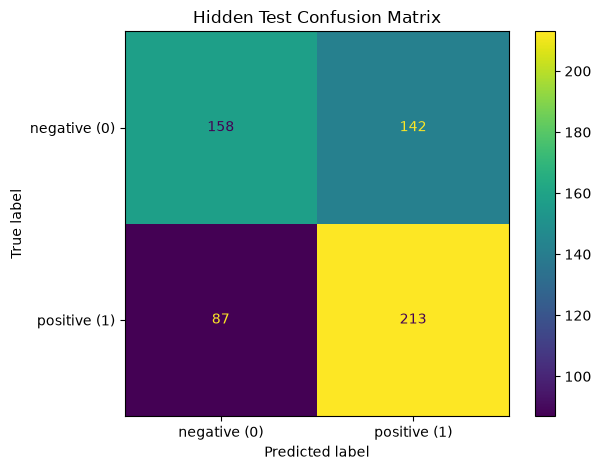

In [8]:
display = ConfusionMatrixDisplay(
    confusion_matrix=hidden_confusion_matrix,
    display_labels=["negative (0)", "positive (1)"],
)
display.plot(values_format="d")
plt.title("Hidden Test Confusion Matrix")
plt.tight_layout()
plt.show()

## Public Test vs. Hidden Test

The next cell recomputes the Stage 1 public-test accuracy from the existing public files if both are present. It does not train on the public test set.

In [9]:
public_accuracy = None

if PUBLIC_TEST_PATH.exists() and PUBLIC_PREDICTIONS_PATH.exists():
    public_df = pd.read_csv(PUBLIC_TEST_PATH)
    public_predictions_df = pd.read_csv(PUBLIC_PREDICTIONS_PATH)

    if set(public_predictions_df.columns) != {"id", "predicted_label"}:
        raise ValueError(
            "public_test_predictions.csv must contain id and predicted_label columns."
        )

    public_eval = public_df[["id", "label"]].merge(
        public_predictions_df,
        on="id",
        how="inner",
        validate="one_to_one",
    )

    if len(public_eval) != len(public_df):
        raise ValueError("Public predictions do not match all public-test ids.")

    public_accuracy = accuracy_score(
        public_eval["label"].astype(int),
        public_eval["predicted_label"].astype(int),
    )

    difference = hidden_accuracy - public_accuracy
    print(f"Public-test accuracy: {public_accuracy:.4f}")
    print(f"Hidden-test accuracy: {hidden_accuracy:.4f}")
    print(f"Hidden minus public: {difference:+.4f}")
else:
    print("Public-test files were not found, so only hidden-test accuracy is reported here.")

Public-test accuracy: 0.6000
Hidden-test accuracy: 0.6183
Hidden minus public: +0.0183


## Short Comparison and Reflection

The public and hidden test sets are both balanced, so accuracy can be compared directly. A small difference between the two results would be expected because they contain different reviews. The confusion matrix is also useful because it shows whether the model makes more mistakes on one sentiment class than the other.

The Stage 1 design used a frozen pretrained sentence encoder and a class-balanced logistic-regression classifier. This kept the number of trainable parameters small, which was useful because the released training set contained only 240 examples and was imbalanced. The pretrained encoder also gives the model representations for words and phrases that were not present in the small released training set.

If I had more time or compute, I would compare several pretrained encoders and use repeated stratified validation on the Stage 1 training data to make model selection less dependent on one split. I would also compare the current frozen-embedding approach with a carefully regularized lightweight fine-tuning approach. Those would be future experiments only; the submitted Stage 1 checkpoint is not changed for this Stage 2 evaluation.

## Save Required Hidden-Test Predictions

In [10]:
hidden_predictions_df = pd.DataFrame(
    {
        "id": hidden_df["id"],
        "predicted_label": hidden_predictions,
    }
)

hidden_predictions_df.to_csv(PREDICTIONS_PATH, index=False)

saved_predictions = pd.read_csv(PREDICTIONS_PATH)
if saved_predictions.columns.tolist() != ["id", "predicted_label"]:
    raise ValueError("Prediction CSV columns are not in the required order.")

if len(saved_predictions) != len(hidden_df):
    raise ValueError("Prediction CSV does not contain one row per hidden example.")

if not set(saved_predictions["predicted_label"]).issubset({0, 1}):
    raise ValueError("Prediction CSV contains a label other than 0 or 1.")

print(f"Saved {PREDICTIONS_PATH} with {len(saved_predictions)} predictions.")
saved_predictions.head()

Saved hidden_test_predictions.csv with 600 predictions.


,id,predicted_label
0,neg_cv795_10291,1
1,neg_cv174_9735,0
2,pos_cv065_15248,1
3,neg_cv076_26009,0
4,neg_cv417_14653,1


## Save Stage 2 Evaluation Writeup

In [11]:
tn, fp, fn, tp = hidden_confusion_matrix.ravel()

if public_accuracy is None:
    comparison_text = (
        "The Stage 1 public-test files were not available when this notebook was run, "
        "so the public-test accuracy was not recomputed in Stage 2."
    )
else:
    difference = hidden_accuracy - public_accuracy
    comparison_text = (
        f"The public-test accuracy was {public_accuracy:.4f}, while the hidden-test "
        f"accuracy was {hidden_accuracy:.4f}. The hidden result differed from the "
        f"public result by {difference:+.4f}. Both evaluation sets are balanced, so "
        "their total accuracies can be compared directly."
    )

evaluation_text = f"""# Stage 2 Hidden Test Evaluation

## Hidden Test Result

The exact Stage 1 checkpoint was reloaded and used for inference only. No retraining, fine-tuning, or checkpoint modification was performed.

- Hidden-test examples: {len(hidden_df)}
- Hidden-test accuracy: {hidden_accuracy:.4f}
- True negatives: {tn}
- False positives: {fp}
- False negatives: {fn}
- True positives: {tp}

## Public vs. Hidden Test

{comparison_text}

## What I Would Try Next

If I had more time or compute, I would compare several pretrained sentence encoders and use repeated stratified validation on the Stage 1 training set. I would also compare the frozen-embedding approach with a carefully regularized lightweight fine-tuning approach. These would be future experiments only; the Stage 1 checkpoint used for this evaluation was not changed.
"""

EVALUATION_PATH.write_text(evaluation_text, encoding="utf-8")
print(f"Saved {EVALUATION_PATH}")

Saved hidden_test_evaluation.md


## Final Stage 2 Check

Before committing Stage 2, confirm that the repository adds only the Stage 2 files required by the assignment. Do **not** edit or replace `stage1_notebook.ipynb` or anything inside `model_checkpoint/` after the Stage 1 deadline.

In [12]:
print("Stage 2 outputs:")
print(f"- {PREDICTIONS_PATH}")
print(f"- {EVALUATION_PATH}")
print("\nStage 1 checkpoint was loaded for inference only.")

Stage 2 outputs:
- hidden_test_predictions.csv
- hidden_test_evaluation.md

Stage 1 checkpoint was loaded for inference only.
